## Anomaly Detection: Isolation Forest

In [44]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[1]))
from src.utils import conf_matrix

In [45]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('../../data/processed/creditcard-processed.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Model Creation

In [46]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, random_state=42, stratify=y
)

xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.0017,
    random_state=42
)

iso.fit(xtrain_scaled)
iso_predict = iso.predict(xtest_scaled)
iso_predict_map = np.where(iso_predict == -1, 1, 0)
raw_scores = iso.decision_function(xtest_scaled)
anomaly_sc = -raw_scores

roc_score = roc_auc_score(ytest, anomaly_sc)
print(f"ROC - AUC Score: {roc_score:.3f}")
print(classification_report(ytest, iso_predict_map))

ROC - AUC Score: 0.946
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.20      0.19      0.20       118

    accuracy                           1.00     70932
   macro avg       0.60      0.60      0.60     70932
weighted avg       1.00      1.00      1.00     70932



## ROC Curve

Text(0.5, 1.0, 'Isolation Forest ROC Curve')

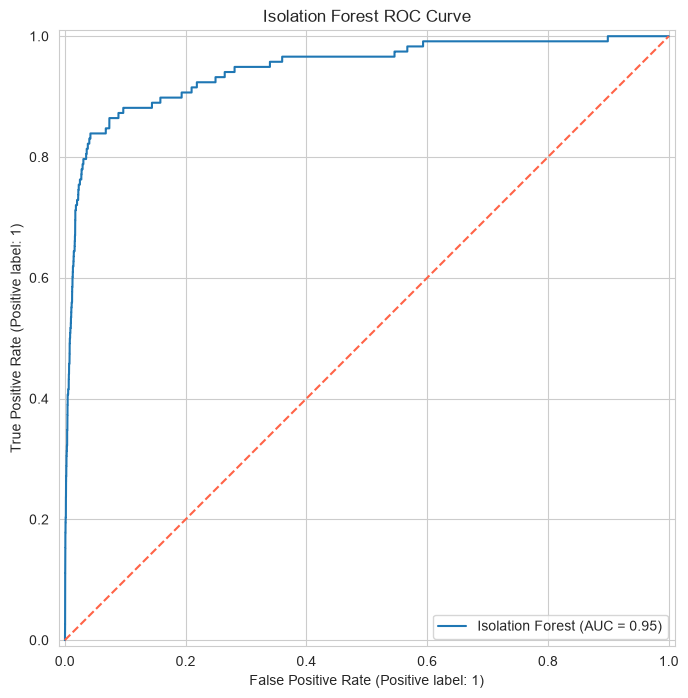

In [47]:
fig, ax = plt.subplots(figsize=(11, 8))

RocCurveDisplay.from_predictions(
    ytest,
    anomaly_sc,
    name='Isolation Forest',
    ax=ax
)
ax.plot([0, 1], [0, 1], linestyle='--', color='tomato')
ax.set_title('Isolation Forest ROC Curve')

## Anomaly Detection

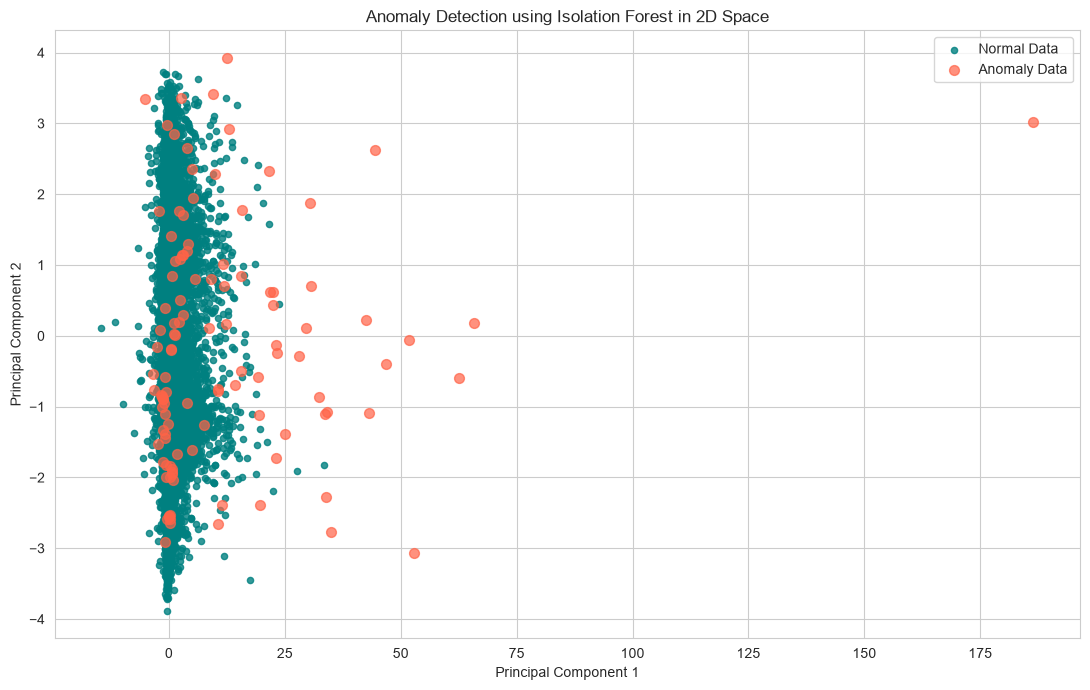

In [48]:
pca = PCA(
    n_components=2,
    random_state=42
)

xtest_pca = pca.fit_transform(xtest_scaled)

transformed_df = pd.DataFrame(xtest_pca, columns=['principal_component_1', 'principal_component_2'])
transformed_df['predict'] = iso_predict

normal = transformed_df[transformed_df['predict'] == 1]
anomaly = transformed_df[transformed_df['predict'] == -1]

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(normal['principal_component_1'], 
           normal['principal_component_2'], color='teal', alpha=0.8, s=20,
           label='Normal Data')

ax.scatter(anomaly['principal_component_1'], 
           anomaly['principal_component_2'], 
           alpha=0.7, color='tomato', s=50,
           label='Anomaly Data')
ax.legend()
ax.set_title('Anomaly Detection using Isolation Forest in 2D Space')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.tight_layout()

## Confusion Matrix

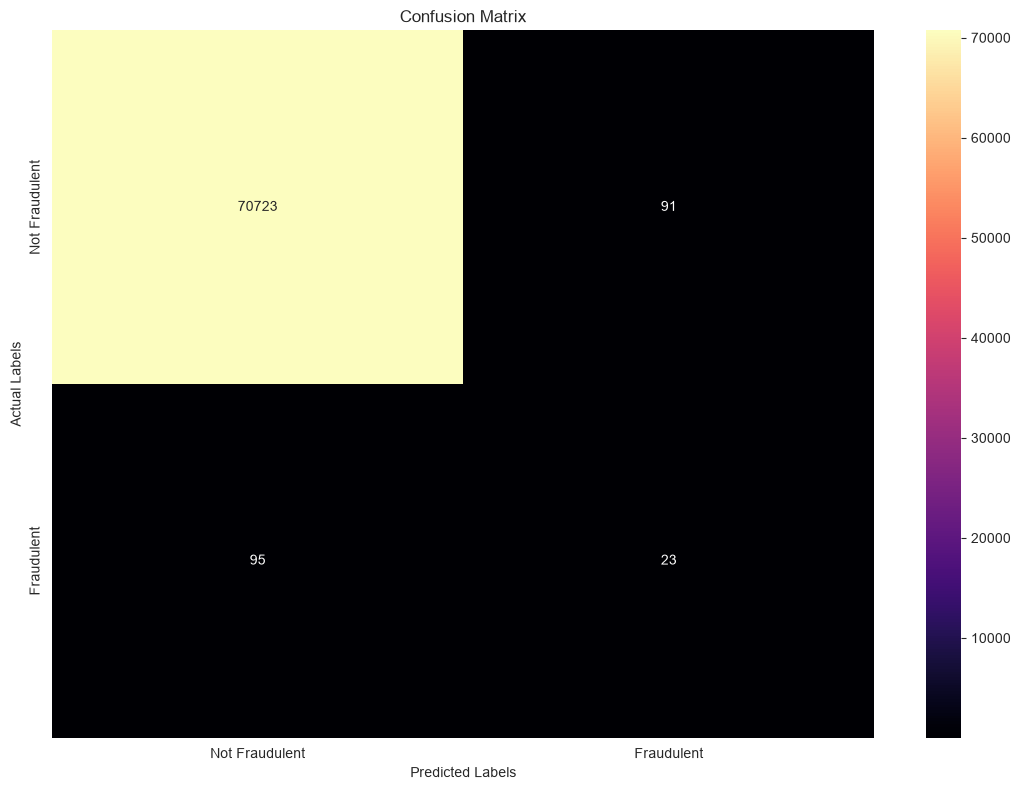

In [49]:
conf_matrix(ytest, iso_predict_map, ['Not Fraudulent', 'Fraudulent'])